# Constrained optimization - SEGO


In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smt_optim.benchmarks.registry import get_problem

from smt_optim.core import Driver, ObjectiveConfig, ConstraintConfig, DriverConfig, Problem

from smt_optim.surrogate_models.smt import SmtAutoModel

from smt_optim.acquisition_strategies import MFSEGO

from smt_optim.surrogate_models.smt import SmtGPX

### Importing a test function

In [2]:
problem = get_problem("Branin1")

## Constrained 2D optimization

As with unconstrained optimisation, we must first define the problem. The objective is configured using the ObjectiveConfig data class, and each constraint must be defined using the ConstraintConfig data class.

In [3]:
obj_config = ObjectiveConfig(
    [problem.objective[-1]],
    type="minimize",
    surrogate=SmtGPX,
)

# configure the constraint
cstr_config = ConstraintConfig(
    [problem.constraints[0][-1]],
    upper=0.0,                      # g(x) <= 0
    surrogate=SmtGPX,         # set which GP to model this constraint
)

prob_definition = Problem(
    obj_configs=[obj_config],
    design_space=problem.bounds,    # problem bounds
    cstr_configs=[cstr_config],     # list the constraints
)

opt_config = DriverConfig(
    max_iter = 10,
    nt_init = 6,
    verbose = True,
    scaling = True,
    seed=42,
)

driver = Driver(prob_definition, opt_config, MFSEGO, strategy_kwargs={"n_start":10, "sp_method": "SLSQP"})

state = driver.optimize()

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             1              7    6.86090e+01      0.000e+00              1          0.037          0.053
             2              8    1.45399e+01      0.000e+00              1          0.044          0.045
             3              9    7.19746e+00      0.000e+00              1          0.044          0.049
             4             10    7.19746e+00      0.000e+00              1          0.047          0.039
             5             11    6.94315e+00      6.076e-08              1          0.041          0.061
             6             12    6.94314e+00      0.000e+00              1          0.043          0.038
             7             13    6.94314e+00      0.000e+00              1          0.044          0.061
             8             14    6.94314e+00      0.000e+00              1          0.059          0.079
             9             15    6.94314e+00      0.000

The `get_best_sample` class method enables us to obtain the optimal sample within a specific constraint tolerance by passing the `ctol` argument. The code snippet below demonstrates how imposing a stricter tolerance constraint can affect the best sample found.

In [4]:
tolerances = [1.2e-1, 1e-4]

for tol in tolerances:
    sample = state.get_best_sample(ctol=tol)
    print(sample)


======= sample data =======
x =             [0.12899267 0.74173099]
obj =           [2.00404723]
cstr =          [0.10432214]
eval_time =     [4.56100679e-06 5.37984306e-07]
------- meta data -------
iter =     0
budget =     2
fidelity =     0
rscv =     0.10432213569325897

======= sample data =======
x =             [1.         0.20020248]
obj =           [6.94314067]
cstr =          [-0.00020248]
eval_time =     [1.40369812e-05 1.82198710e-06]
------- meta data -------
iter =     7
budget =     13
fidelity =     0
rscv =     0.0



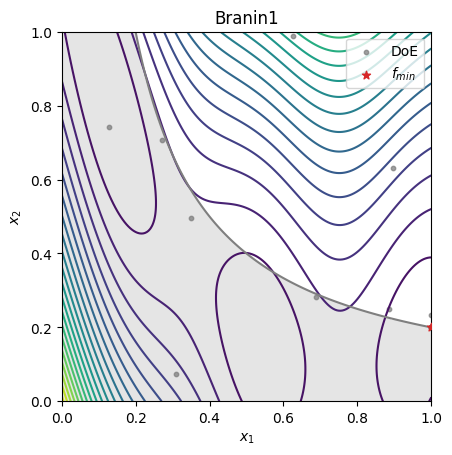

In [5]:
# get the best sample in the dataset
sample = state.get_best_sample(ctol=1e-4)
xt = state.dataset.export_as_dict()["x"]

X = np.linspace(0, 1, 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])
    c[i] = problem.constraints[0][-1](data[i, :])

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(xt[:, 0], xt[:, 1], 10, color="C7", alpha=0.75, label="DoE")
ax.scatter(sample.x[0], sample.x[1], c="C3", marker="*", label=r"$f_{min}$", zorder=10)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()